In [65]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

In [ ]:
housing.head()

In [45]:
# housing["ocean_proximity"].value_counts()
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

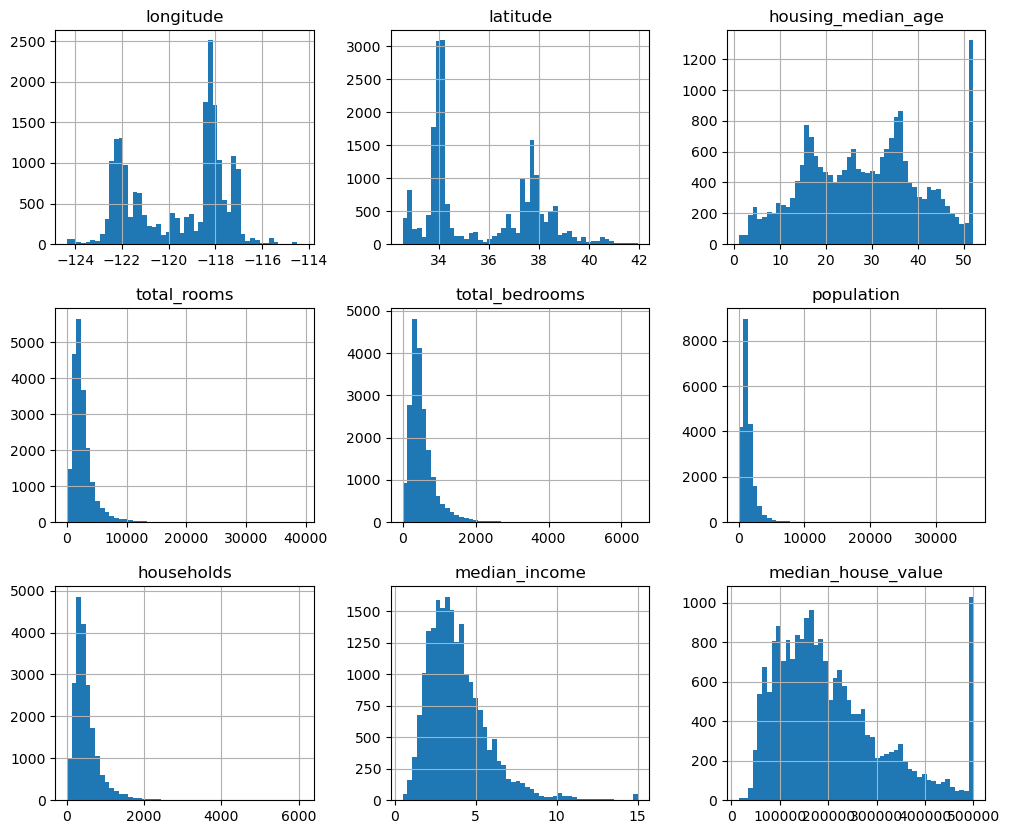

In [39]:

housing.hist(bins=50, figsize = (12,10))

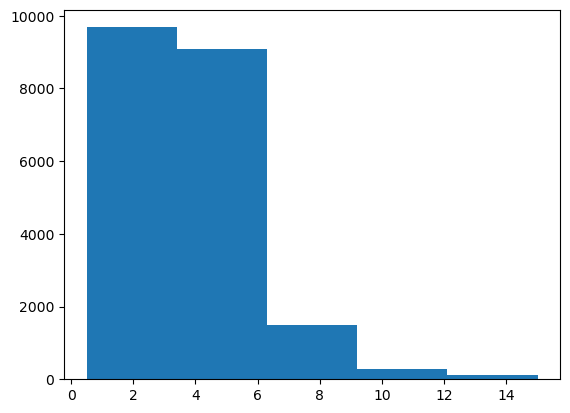

In [40]:
hists = plt.hist(housing["median_income"], bins=5)
housing["income_cat"] = pd.cut(housing['median_income'], bins=hists[1], labels=[1,2,3,4,5])

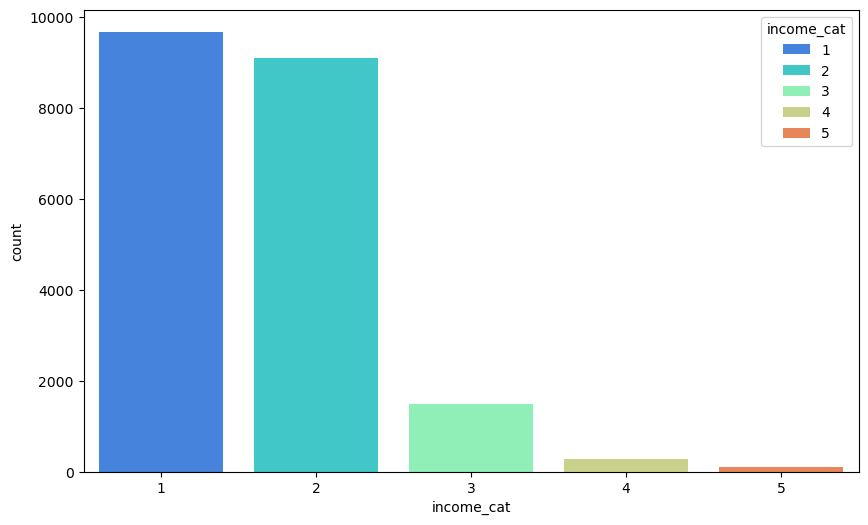

In [41]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(10,6))
sns.countplot(data=housing, x='income_cat', ax=ax, palette='rainbow', hue='income_cat')
plt.show()

In [ ]:
sample = housing.dropna(inplace=True)
sample['income_cat'] = sample.loc[:, 'income_cat'].astype(int)

C:\Users\Playdata\AppData\Local\Temp\ipykernel_20784\1684445940.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample['income_cat'] = sample.loc[:, 'income_cat'].astype(int)


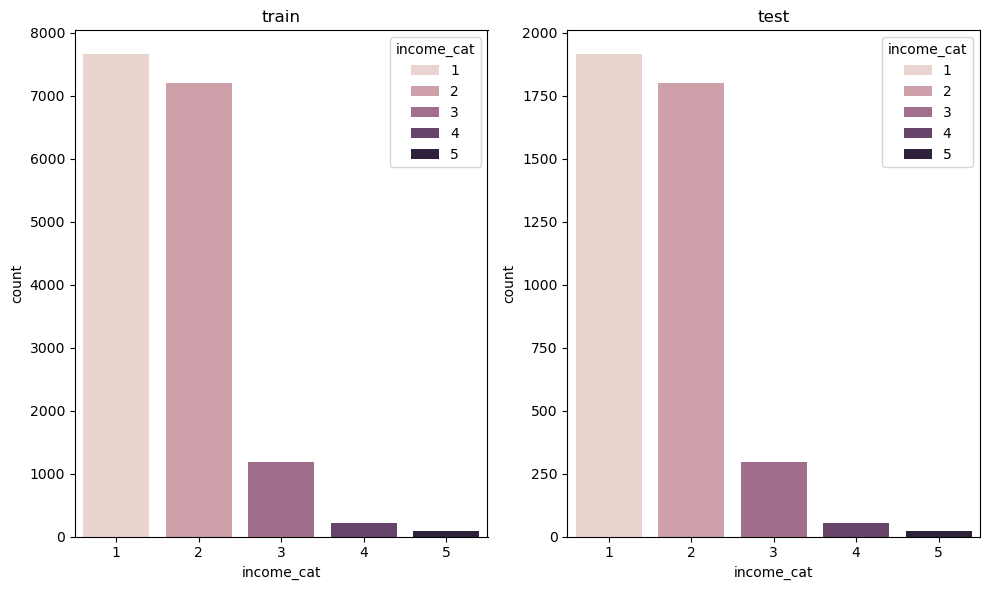

In [63]:
train, test = train_test_split(sample, test_size=0.2,# random_state=42,
                                stratify=sample['income_cat'])

fig, axes = plt.subplots(1,2,figsize = (10,6))
axes[0].set_title('train')
axes[1].set_title('test')
sns.countplot(data=train, x='income_cat', hue='income_cat', ax=axes[0])
sns.countplot(data=test, x='income_cat', hue='income_cat', ax=axes[1])
plt.tight_layout()
plt.show()

In [53]:
origin = housing['income_cat'].value_counts() / len(housing) 
train_diff = train['income_cat'].value_counts() / len(train) 
test_diff = test['income_cat'].value_counts() / len(test) 
train_diff, test_diff

(income_cat
 1    0.468597
 2    0.440744
 3    0.072233
 4    0.013100
 5    0.005326
 Name: count, dtype: float64,
 income_cat
 1    0.468543
 2    0.440881
 3    0.072215
 4    0.012974
 5    0.005386
 Name: count, dtype: float64)

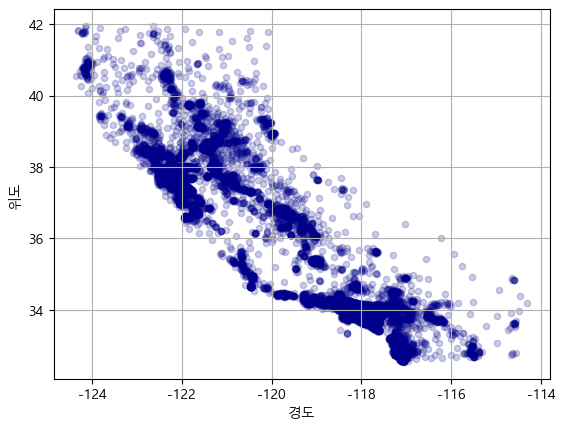

In [68]:
housing.plot(kind='scatter', x='longitude', y='latitude', grid=True, alpha = 0.2, color = 'darkblue')
plt.xlabel('경도')
plt.ylabel('위도')
plt.show()

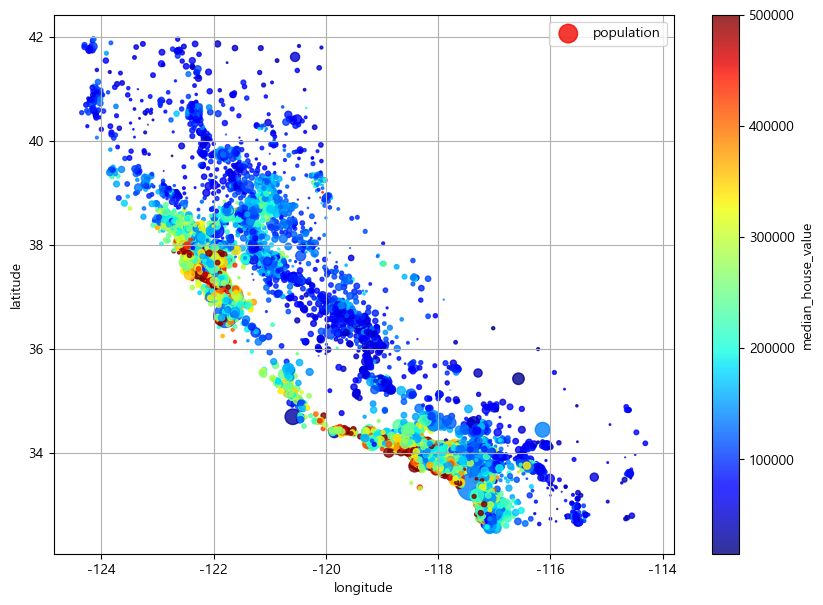

In [72]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha = 0.8,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, figsize=(10, 7))
plt.show()